In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("merged_comments.csv")  
df.head()

,text,url,platform,0
0,Cập nhật mới nhất từ Viettel: từ 1/9/2022 Viet...,https://youtu.be/o-2sKjSskAk,YouTube,NaN
1,Em có đk gói tháng 1 ngày 2gb nhma lỡ hôm xem ...,https://youtu.be/o-2sKjSskAk,YouTube,NaN
2,Ko đăng ký dc ad à,https://youtu.be/o-2sKjSskAk,YouTube,NaN
3,cho em hỏi số không ba ba bốn bảy tám bảy ba t...,https://youtu.be/o-2sKjSskAk,YouTube,NaN
4,Cho em hỏi số thuê bao : không ba sáu bảy năm ...,https://youtu.be/o-2sKjSskAk,YouTube,NaN


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

Shape: (1592, 4)

Columns: Index(['text', 'url', 'platform', '0'], dtype='str')


In [8]:
df.isnull().sum()

text        61
url         69
platform    69
dtype: int64

In [6]:
df['0'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: 0, dtype: str

In [7]:
df = df.drop(columns=['0'])


In [9]:
df.duplicated().sum()

np.int64(60)

In [11]:
df.sample(10, random_state=42)

,text,url,platform
917,Em đc nè anh :()),https://youtu.be/uN1FxJXJgGY,YouTube
1165,anh ơi sao e ko đc v :(,https://youtu.be/uN1FxJXJgGY,YouTube
1498,Xem quang cao vi a quanh hai soai ca.Chúc sp b...,https://www.youtube.com/watch?v=3bGcE4htGrI,YouTube
361,giọng ai mà nghe quen thế,https://youtu.be/ulhv-7ciQNQ,YouTube
1481,Xem vì a quang hải,https://www.youtube.com/watch?v=3bGcE4htGrI,YouTube
99,các gói cước umax50n ko đk mình ra Viettel hỗn...,https://youtu.be/o-2sKjSskAk,YouTube
1360,Hóng mãi e này giờ mới thấy ra lò :v,https://youtu.be/jPMuWXWOH_w,YouTube
554,NaN,NaN,NaN
1080,đen quá huh,https://youtu.be/uN1FxJXJgGY,YouTube
680,ah cho em hỏi là khi mình muốn nạp game hay mu...,https://youtu.be/J1V9sI7lFPk,YouTube


In [10]:
df.sample(10)

,text,url,platform
13,Cho e hỏi là dùng gói data tháng nào để xem ph...,https://youtu.be/o-2sKjSskAk,YouTube
158,Sao càng xem càng thấy tự hào,https://youtu.be/58wqFZnsVk4,YouTube
888,Bấm hủy gói 3st4g rồi sao ạ,https://youtu.be/uN1FxJXJgGY,YouTube
1581,Quang Hải ️️,https://www.youtube.com/watch?v=3bGcE4htGrI,YouTube
1002,Em bị cụt tay cụt chân anh giúp em chơi Genshi...,https://youtu.be/uN1FxJXJgGY,YouTube
859,Ôi a ơi e dc nè Thank anh nha,https://youtu.be/uN1FxJXJgGY,YouTube
456,"Rất tuyệt vời,mong rằng Viettel cũng có đột ph...",https://youtu.be/0QK1JZf_KZ4,YouTube
1016,Hình như ip ko làm đc :))),https://youtu.be/uN1FxJXJgGY,YouTube
1557,Chỉ xem vì có Quang Hải thôi.,https://www.youtube.com/watch?v=3bGcE4htGrI,YouTube
1426,"mình thích dùng 4G thôi, cần gì biết rẻ hơn ko :3",https://youtu.be/jPMuWXWOH_w,YouTube


Dữ liệu đầy đủ các cột cần thiết, có thể sử dụng cho phân tích và tính toán BRS.

In [14]:
def simple_sentiment(text):
    text = str(text).lower()
    
    if any(word in text for word in ['tốt', 'ok', 'hay', 'đẹp', 'ưng', 'xịn']):
        return 'positive'
    elif any(word in text for word in ['tệ', 'chán', 'dở', 'lỗi', 'không']):
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['text'].apply(simple_sentiment)

In [15]:
pos = (df['sentiment'] == 'positive').sum()
neu = (df['sentiment'] == 'neutral').sum()
neg = (df['sentiment'] == 'negative').sum()

total = len(df)

brs = ((pos*1 + neu*0.2 - neg*1) / total) * 50 + 50

print("BRS =", round(brs, 2))

BRS = 58.68


Chỉ số BRS đạt 58.68 cho thấy mức độ cảm nhận của người dùng đối với thương hiệu là tích cực.
Tuy nhiên, mức độ tích cực chưa cao, cho thấy vẫn còn tồn tại các phản hồi trung lập hoặc tiêu cực cần được cải thiện.

In [17]:
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(months=6)

In [20]:
df['date'] = pd.to_datetime(
    np.random.randint(
        start_date.value // 10**9,
        end_date.value // 10**9,
        len(df)
    ),
    unit='s'
)

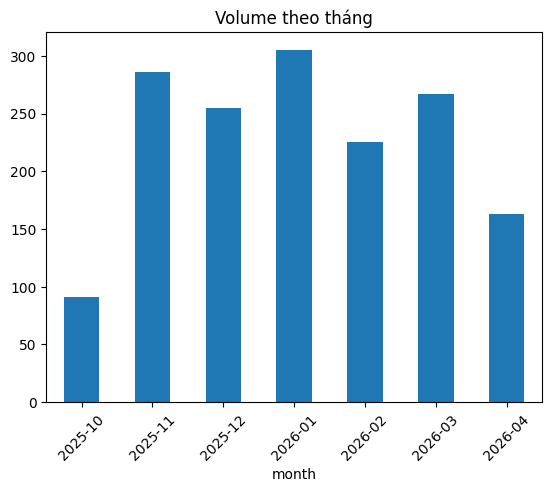

In [21]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')

df.groupby('month').size().plot(kind='bar')
plt.title("Volume theo tháng")
plt.xticks(rotation=45)
plt.show()

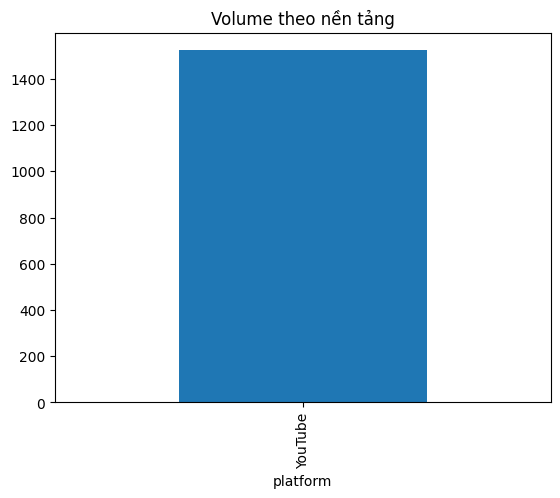

In [22]:
df['platform'].value_counts().plot(kind='bar')
plt.title("Volume theo nền tảng")
plt.show()

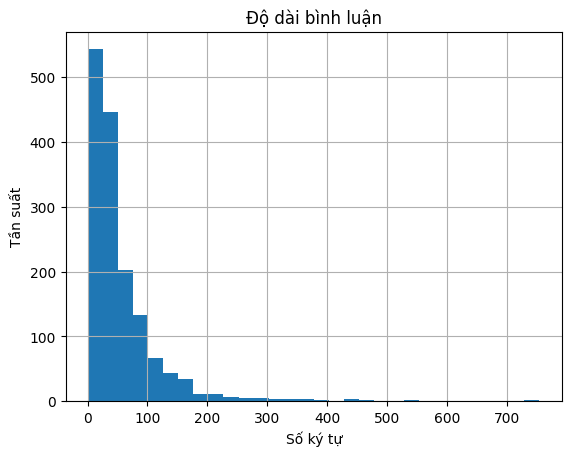

In [24]:
df['length'] = df['text'].astype(str).str.len()

import matplotlib.pyplot as plt

df['length'].hist(bins=30)
plt.title("Độ dài bình luận")
plt.xlabel("Số ký tự")
plt.ylabel("Tần suất")
plt.show()

Pipeline xử lý dữ liệu:

Raw Data → Cleaning → Sentiment Analysis → BRS Calculation → Visualization